# Walsh-Space Analysis of Distributed Memory, Attractor Dynamics, and Stable-Wrong Convergence

**DLMH Programme — Jonathan West**

---

## What this notebook is

This notebook provides a mathematical demonstration of a single central claim:

> **A system can be highly consistent and completely wrong.**

That claim is the mechanistic foundation of the Distributed-Like Memory Hypothesis (DLMH), which proposes that hallucinations in AI language models and confabulations in human memory arise from the same underlying process: **reconstruction under insufficient constraint**.

We demonstrate this using a minimal Hopfield-style neural memory model — a well-established mathematical framework in computational neuroscience. No neural network training is required. The model is small enough to inspect completely, which makes the mechanism transparent.

---

## The four things this notebook shows

| Section | Question | Key result |
|---|---|---|
| 1. The landscape | What does a memory system look like geometrically? | A landscape of energy basins — stored patterns are valleys |
| 2. Trajectories | How does recall work? | As a path descending toward the nearest basin |
| 3. Walsh analysis | How complex is the landscape? | More stored patterns = richer interaction structure |
| 4. Three regimes | Can a system be stably wrong? | Yes — and this is the same phenomenon seen in LLMs |
| 5. Degradation | Does correctness persist across steps? | No — constraint closure is local, not global |

---

## Note on the mathematics

This notebook uses **Walsh-Hadamard analysis** to characterise the energy landscape. You do not need to understand the transform to follow the argument. Think of it as a way of asking: *how much of the landscape's structure comes from simple biases, how much from pairwise interactions, and how much from higher-order interactions?* The answer changes as more patterns are stored, and that change matters for understanding why interference and stable-wrong convergence occur.

For readers who want only the conceptual results: focus on the figures and the interpretation cells. The code cells are the machinery behind them.


## Setup

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.set_printoptions(suppress=True, linewidth=120)
rng = np.random.default_rng(7)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})


## Core functions

All functions used throughout the notebook. You can skip reading these and return if you want to understand a specific detail.

In [2]:
def generate_states(n):
    """All 2^n states on the Boolean hypercube {-1,+1}^n."""
    return np.array(list(itertools.product([-1, 1], repeat=n)), dtype=int)

def hebbian_weights(patterns):
    """Hebbian outer-product rule: encodes patterns as distributed constraint structure."""
    n = len(patterns[0])
    W = np.zeros((n, n), dtype=float)
    for p in patterns:
        W += np.outer(p, p)
    np.fill_diagonal(W, 0)
    return W / n

def energy(x, W):
    """Hopfield energy: E(x) = -0.5 * x^T W x. Lower = more stable."""
    return -0.5 * x @ W @ x

def async_update(x, W, bias=None, order=None):
    """One asynchronous update pass across all units."""
    x = x.copy().astype(int)
    n = len(x)
    if bias is None:
        bias = np.zeros(n, dtype=float)
    if order is None:
        order = range(n)
    for i in order:
        h = np.dot(W[i], x) + bias[i]
        x[i] = 1 if h >= 0 else -1
    return x

def run_until_convergence(x0, W, bias=None, max_steps=10, rng=None):
    """Run dynamics from cue x0 until convergence. Returns trajectory and energy sequence."""
    if rng is None:
        rng = np.random.default_rng(0)
    x = x0.copy().astype(int)
    trajectory = [x.copy()]
    energies = [energy(x, W)]
    for _ in range(max_steps):
        order = rng.permutation(len(x))
        x_new = async_update(x, W, bias=bias, order=order)
        trajectory.append(x_new.copy())
        energies.append(energy(x_new, W))
        if np.array_equal(x_new, x):
            break
        x = x_new
    return np.array(trajectory), np.array(energies)

def hadamard_matrix(N):
    if N == 1:
        return np.array([[1]], dtype=float)
    H = hadamard_matrix(N // 2)
    return np.block([[H, H], [H, -H]])

def walsh_coefficients(values):
    """Walsh-Hadamard transform of energy values over all states."""
    values = np.asarray(values, dtype=float)
    N = len(values)
    H = hadamard_matrix(N)
    return (H @ values) / np.sqrt(N)

def bitcount(i):
    return bin(i).count("1")

def perturb_state(x, flip_prob=0.2, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    x = x.copy()
    mask = rng.random(len(x)) < flip_prob
    x[mask] *= -1
    return x

def run_trials(x0, W, target, trials=200, steps=5, bias=None, flip_prob=0.25, seed=0):
    """
    Run many recall trials from a perturbed version of x0.
    Returns stability (how consistent), accuracy (how correct), and modal output.
    """
    rng = np.random.default_rng(seed)
    results = []
    for _ in range(trials):
        x = perturb_state(x0, flip_prob=flip_prob, rng=rng)
        for _ in range(steps):
            order = rng.permutation(len(x))
            x = async_update(x, W, bias=bias, order=order)
        results.append(tuple(x))
    results = np.array(results)
    unique, counts = np.unique(results, axis=0, return_counts=True)
    mode_idx = np.argmax(counts)
    mode = unique[mode_idx]
    stability = counts[mode_idx] / trials
    accuracy = np.mean([np.array_equal(r, target) for r in results])
    return {"stability": stability, "accuracy": accuracy,
            "mode": mode, "distribution": dict(zip(map(tuple, unique), counts))}

def hamming(a, b):
    return np.sum(a != b)

# Initialise the system
n = 3
states = generate_states(n)
pattern_1 = np.array([1,  1, -1], dtype=int)   # Target pattern / stored memory
pattern_2 = np.array([-1, 1,  1], dtype=int)   # Second pattern for interference demo
W1 = hebbian_weights([pattern_1])
W2 = hebbian_weights([pattern_1, pattern_2])

print(f"System: n={n} units, {len(states)} possible states")
print(f"Stored pattern 1: {pattern_1}")
print(f"Stored pattern 2: {pattern_2}")
print(f"\nWeight matrix W (one pattern):")
print(W1)


System: n=3 units, 8 possible states
Stored pattern 1: [ 1  1 -1]
Stored pattern 2: [-1  1  1]

Weight matrix W (one pattern):
[[ 0.          0.33333333 -0.33333333]
 [ 0.33333333  0.         -0.33333333]
 [-0.33333333 -0.33333333  0.        ]]


---

## Section 1: The Energy Landscape

**Question: what does a memory system look like geometrically?**

A Hopfield network stores memories not as discrete locations but as a **landscape of constraint**. Each possible state of the system has an energy value. States corresponding to stored memories are energy minima — valleys, or basins, in the landscape. All other states are higher energy and therefore unstable.

When the system is given a cue — a partial or noisy version of a stored pattern — it evolves toward the nearest low-energy state. This is the **attractor** dynamics that underlies recall.

The figure below shows the energy of every possible state for:
- a system with **one stored pattern** (left)
- a system with **two stored patterns** (right)

Each node is a possible state. Colour indicates energy: **green = low energy (attractor basin)**, **red = high energy (unstable)**. Edges connect states that differ by a single unit flip — the smallest possible step in the landscape.

**What to look for:** in the one-pattern case, there are two deep basins (the stored pattern and its mirror image). In the two-pattern case, the landscape becomes more complex — more basins, more potential for a noisy cue to fall into the wrong one.


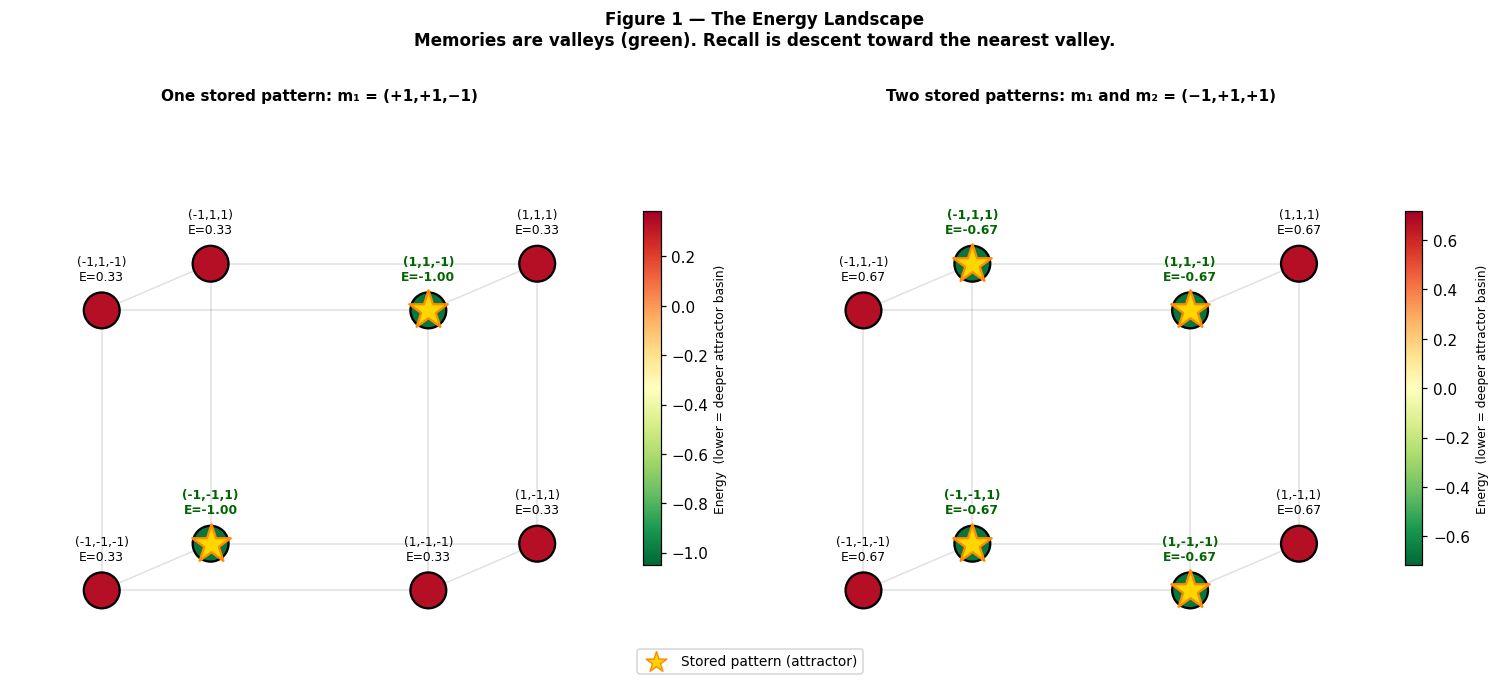

In [3]:
energies_1 = np.array([energy(s, W1) for s in states])
energies_2 = np.array([energy(s, W2) for s in states])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, energies, title, patterns in [
    (axes[0], energies_1, "One stored pattern: m₁ = (+1,+1,−1)", [pattern_1]),
    (axes[1], energies_2, "Two stored patterns: m₁ and m₂ = (−1,+1,+1)", [pattern_1, pattern_2]),
]:
    emin, emax = energies.min(), energies.max()

    # 2D projection: use bits to spread states across the plane
    xs = np.array([s[0]*0.9 + s[2]*0.3 for s in states])
    ys = np.array([s[1]*0.9 + s[2]*0.15 for s in states])

    # Draw edges between Hamming-1 neighbours first
    for i, si in enumerate(states):
        for j, sj in enumerate(states):
            if j <= i:
                continue
            if hamming(si, sj) == 1:
                ax.plot([xs[i], xs[j]], [ys[i], ys[j]],
                        'k-', alpha=0.12, linewidth=1, zorder=1)

    # Draw state nodes, coloured by energy
    sc = ax.scatter(xs, ys, c=energies, cmap='RdYlGn_r',
                    s=550, zorder=3, edgecolors='k', linewidths=1.5,
                    vmin=emin - 0.05, vmax=emax + 0.05)

    # Annotate: state vector and energy
    for i, (x, y, s, e) in enumerate(zip(xs, ys, states, energies)):
        is_stored = any(np.array_equal(s, p) or np.array_equal(s, -p) for p in patterns)
        label = f"({','.join(map(str,s))})\nE={e:.2f}"
        ax.annotate(label, (x, y), textcoords="offset points",
                    xytext=(0, 20), ha='center', fontsize=8,
                    fontweight='bold' if is_stored else 'normal',
                    color='darkgreen' if is_stored else 'black')

    # Mark stored patterns explicitly
    for p in patterns:
        for sign in [1, -1]:
            sp = sign * p
            match = np.where([np.array_equal(sp, s) for s in states])[0]
            if len(match):
                ax.scatter(xs[match[0]], ys[match[0]], s=700,
                           marker='*', color='gold', zorder=5,
                           edgecolors='darkorange', linewidths=1.5)

    cb = plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.02)
    cb.set_label("Energy  (lower = deeper attractor basin)", fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.5, 2.0)
    ax.axis('off')

# Legend
star = plt.scatter([], [], marker='*', color='gold', edgecolors='darkorange', s=200)
plt.figlegend(handles=[star], labels=['Stored pattern (attractor)'],
              loc='lower center', ncol=1, fontsize=9, frameon=True)

plt.suptitle("Figure 1 — The Energy Landscape\n"
             "Memories are valleys (green). Recall is descent toward the nearest valley.",
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Interpretation**

The key insight is that **the memory is not stored in any single unit** — it is encoded in the *relationships* between units (the weight matrix W). This distributed encoding is what gives the system its robustness: there is no single point of failure. Damage any one unit and the landscape degrades gracefully.

This is directly analogous to how biological memory appears to work: localised brain damage does not typically erase specific memories, it degrades the quality of reconstruction across many memories.

The second pattern creates a more complex landscape with more basins. This is both useful (more memories) and dangerous (more opportunity for a noisy cue to fall into the wrong basin). The interference between stored patterns is a fundamental property of distributed memory — it is not a bug but an architectural consequence.


---

## Section 2: Recall as Trajectory

**Question: how does recall actually work?**

Recall is not retrieval of a stored state. It is **active reconstruction**: the system starts from a partial or noisy cue and evolves through a sequence of states, descending the energy landscape until it reaches a stable point.

Crucially: **the trajectory is not stored anywhere**. Only the weight matrix W (the constraint structure) is persistent. The trajectory exists only during recall, and different starting points will produce different paths — though they may converge on the same endpoint.

We demonstrate this with two contrasting cases:

- **Left:** a noisy cue in the unbiased system → correctly reconstructs the stored pattern
- **Right:** the same type of cue in a biased system (with an additional field pulling one unit in the wrong direction) → converges to a different, stable, but *wrong* state

Both trajectories descend energy. Both are successful from the system's perspective. Only one arrives at the correct answer.


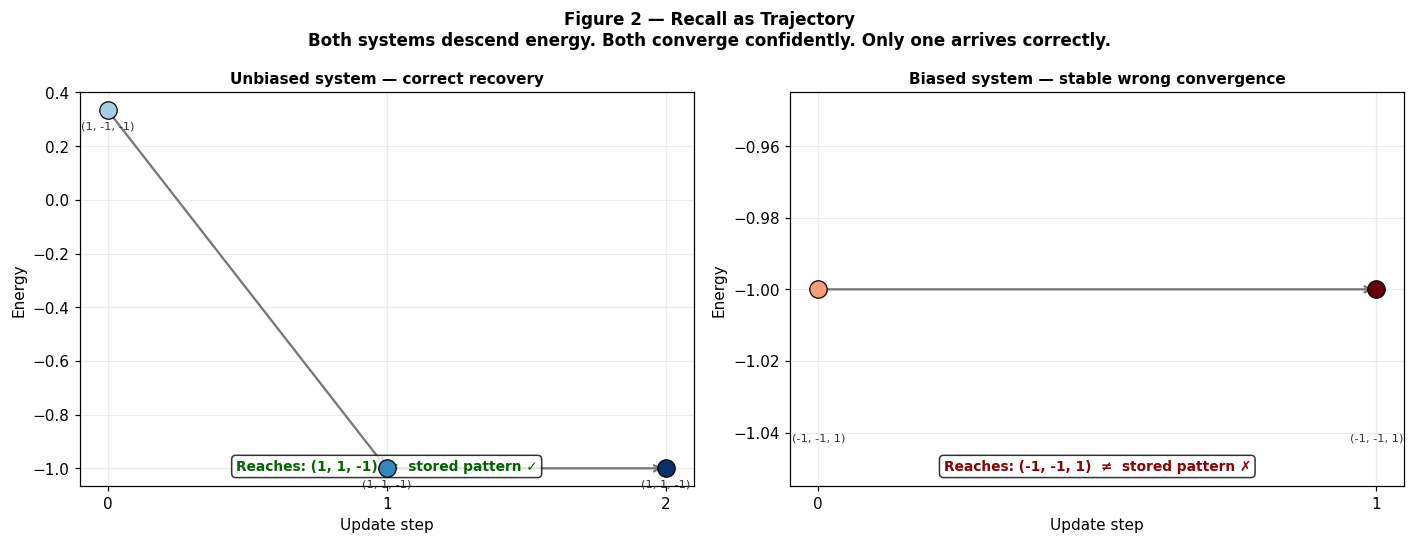

In [4]:
cue_correct = np.array([1, -1, -1], dtype=int)   # noisy cue, recoverable
bias_wrong  = np.array([0.0, 0.0, 2.0])           # field pushing unit 3 wrong
cue_wrong   = np.array([-1, -1, 1], dtype=int)    # cue that leads to wrong basin under bias

traj_correct, tE_correct = run_until_convergence(
    cue_correct, W1, bias=None,       max_steps=10, rng=np.random.default_rng(1))
traj_wrong, tE_wrong     = run_until_convergence(
    cue_wrong,   W1, bias=bias_wrong, max_steps=10, rng=np.random.default_rng(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, traj, tE, color, title, outcome, outcome_color in [
    (axes[0], traj_correct, tE_correct, 'steelblue',
     "Unbiased system — correct recovery",
     f"Reaches: {tuple(traj_correct[-1])}  =  stored pattern ✓", 'darkgreen'),
    (axes[1], traj_wrong, tE_wrong, 'tomato',
     "Biased system — stable wrong convergence",
     f"Reaches: {tuple(traj_wrong[-1])}  ≠  stored pattern ✗", 'darkred'),
]:
    steps = range(len(tE))
    shades = plt.cm.Blues(np.linspace(0.35, 1.0, len(tE))) if color == 'steelblue'              else plt.cm.Reds(np.linspace(0.35, 1.0, len(tE)))

    # Plot energy points and connecting arrows
    for i in range(len(tE)):
        ax.scatter(i, tE[i], color=shades[i], s=130, zorder=4,
                   edgecolors='k', linewidths=0.8)
        if i > 0:
            ax.annotate("", xy=(i, tE[i]), xytext=(i-1, tE[i-1]),
                        arrowprops=dict(arrowstyle="->", color='#777777', lw=1.5))

    # Annotate state at each step
    for i, (s, e) in enumerate(zip(traj, tE)):
        ax.text(i, e - 0.04, str(tuple(s)), ha='center', va='top',
                fontsize=7.5, color='#333333')

    # Outcome label
    ax.text(0.5, 0.04, outcome, transform=ax.transAxes,
            ha='center', fontsize=9, color=outcome_color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_xlabel("Update step", fontsize=10)
    ax.set_ylabel("Energy", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.set_xticks(list(steps))

plt.suptitle("Figure 2 — Recall as Trajectory\n"
             "Both systems descend energy. Both converge confidently. Only one arrives correctly.",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation**

Both trajectories do exactly what the system is designed to do: they find a stable low-energy state. The biased system is not malfunctioning. It is operating correctly, under a different constraint landscape that contains a stronger attractor in the wrong location.

This is the computational signature of **confabulation**: the reconstruction process runs to completion, producing a confident, stable output that happens to be wrong. From the inside, both trajectories feel identical. There is no signal available to the system that one outcome is correct and the other is not.

In human memory terms: the confabulating patient is not lying, and is not aware of any error. Their reconstruction system has converged on the nearest plausible state given the constraints available to it.

> **The trajectory is not stored. The landscape shapes it. Change the landscape, change the outcome.**


---

## Section 3: Landscape Complexity — Walsh-Hadamard Analysis

**Question: what is the internal structure of the energy landscape?**

We can characterise the energy landscape more precisely by asking: *what types of interactions are responsible for its shape?*

The Walsh-Hadamard transform decomposes the energy function into components at different **interaction degrees**:

- **Degree 0 (constant):** the overall average energy across all states
- **Degree 1 (single-node):** simple biases — some units tend to prefer +1 or −1 regardless of others
- **Degree 2 (pairwise):** interactions between pairs of units — the core of Hebbian memory
- **Degree 3 (three-way):** interactions involving all three units simultaneously

A simple landscape is dominated by low-degree terms. A complex landscape has significant high-degree terms — meaning many interacting constraints that can interfere with each other.

**Why does this matter for hallucination?** A landscape with rich high-order structure has more potential interference between stored patterns. A noisy cue is more likely to land in an unintended basin. The model is more likely to confabulate — not because it is "broken" but because the geometry of its learned landscape has become complex enough that incorrect attractors are nearby.


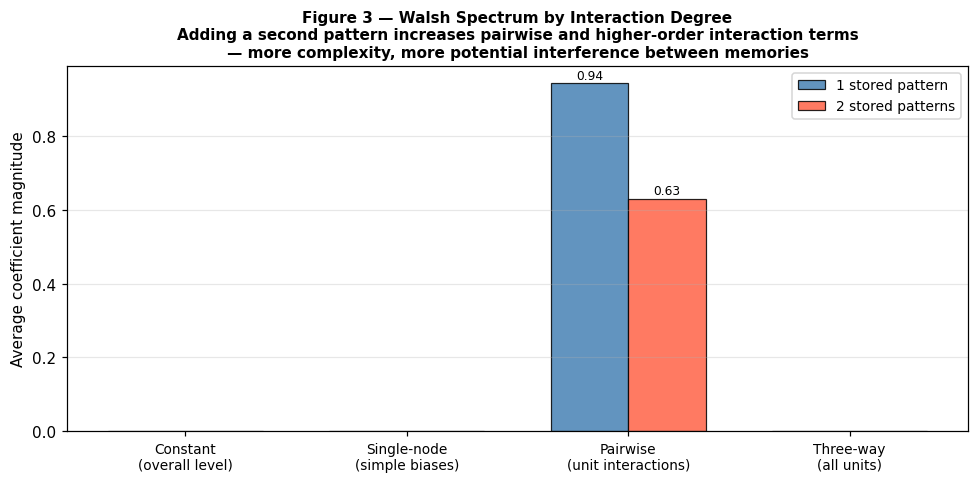

Summary:
Interaction type                1 pattern   2 patterns     Change
------------------------------------------------------------------
Constant                            0.000        0.000          ↓
Single-node                         0.000        0.000          —
Pairwise                            0.943        0.629          ↓
Three-way                           0.000        0.000          —


In [5]:
coeffs_1 = walsh_coefficients(energies_1)
coeffs_2 = walsh_coefficients(energies_2)

degrees = np.array([bitcount(i) for i in range(len(coeffs_1))])
degree_means_1 = [np.mean(np.abs(coeffs_1[degrees == d])) for d in range(n+1)]
degree_means_2 = [np.mean(np.abs(coeffs_2[degrees == d])) for d in range(n+1)]

degree_labels = [
    "Constant\n(overall level)",
    "Single-node\n(simple biases)",
    "Pairwise\n(unit interactions)",
    "Three-way\n(all units)"
]

x = np.arange(n + 1)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))

b1 = ax.bar(x - width/2, degree_means_1, width=width, label="1 stored pattern",
            color='steelblue', alpha=0.85, edgecolor='k', linewidth=0.8)
b2 = ax.bar(x + width/2, degree_means_2, width=width, label="2 stored patterns",
            color='tomato',    alpha=0.85, edgecolor='k', linewidth=0.8)

# Value labels on bars
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f"{h:.2f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(degree_labels, fontsize=9)
ax.set_ylabel("Average coefficient magnitude", fontsize=10)
ax.set_title("Figure 3 — Walsh Spectrum by Interaction Degree\n"
             "Adding a second pattern increases pairwise and higher-order interaction terms\n"
             "— more complexity, more potential interference between memories",
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Summary:")
print(f"{'Interaction type':<28} {'1 pattern':>12} {'2 patterns':>12} {'Change':>10}")
print("-" * 66)
labels_short = ["Constant", "Single-node", "Pairwise", "Three-way"]
for d, (m1, m2, lab) in enumerate(zip(degree_means_1, degree_means_2, labels_short)):
    direction = "↑" if m2 > m1 else ("↓" if m2 < m1 else "—")
    print(f"{lab:<28} {m1:>12.3f} {m2:>12.3f} {direction:>10}")


**Interpretation**

The shift from one to two patterns increases the magnitude of interaction terms, particularly at the pairwise level. This is not surprising — Hebbian learning encodes memories *as* pairwise weights — but the Walsh analysis makes the structure visible and quantifiable.

For our purposes the key message is simple: **a richer memory landscape is a more interference-prone landscape**. The same principle applies to large language models, which have learned from vast amounts of text and consequently have extraordinarily rich, high-order interaction structures. When you give such a model a prompt, you are initialising a trajectory in a landscape shaped by billions of learned constraints. Some of those constraints are much stronger than others — and a strong prior can pull the trajectory away from the correct answer, just as the biased field did in Section 2.

> **The Walsh spectrum is a fingerprint of landscape complexity. More complexity = more potential for stable-wrong convergence.**


---

## Section 4: The Three Behavioural Regimes

**Question: can a system be stably wrong?**

We now introduce the central diagnostic framework of DLMH. Any memory system — biological or artificial — can be characterised along two independent dimensions:

- **Stability:** how consistently does it produce the same output across repeated trials with similar inputs?
- **Accuracy:** how often is that output actually correct?

These dimensions are independent. A system can be:

| Regime | Stability | Accuracy | Interpretation |
|---|---|---|---|
| **Stable Correct** | High | High | Operating well — strong prior matches ground truth |
| **Unstable** | Low | Variable | Weak attractors — cue underdetermines the output |
| **Stable Wrong** | High | Low | **Confabulation** — strong prior overrides the correct answer |

The third regime is what we are most interested in. A system in this state is not producing random errors. It is producing **systematic, confident, repeatable errors**. From the outside, its behaviour looks reliable. From the inside, it has no way of knowing it is wrong.

We demonstrate this by comparing:
- An **unbiased** system: the weight matrix alone determines outcomes
- A **biased** system: an additional field in the wrong direction pulls unit 3 toward the wrong value

The arrows in the figure show how the bias moves each starting point from one regime to another.


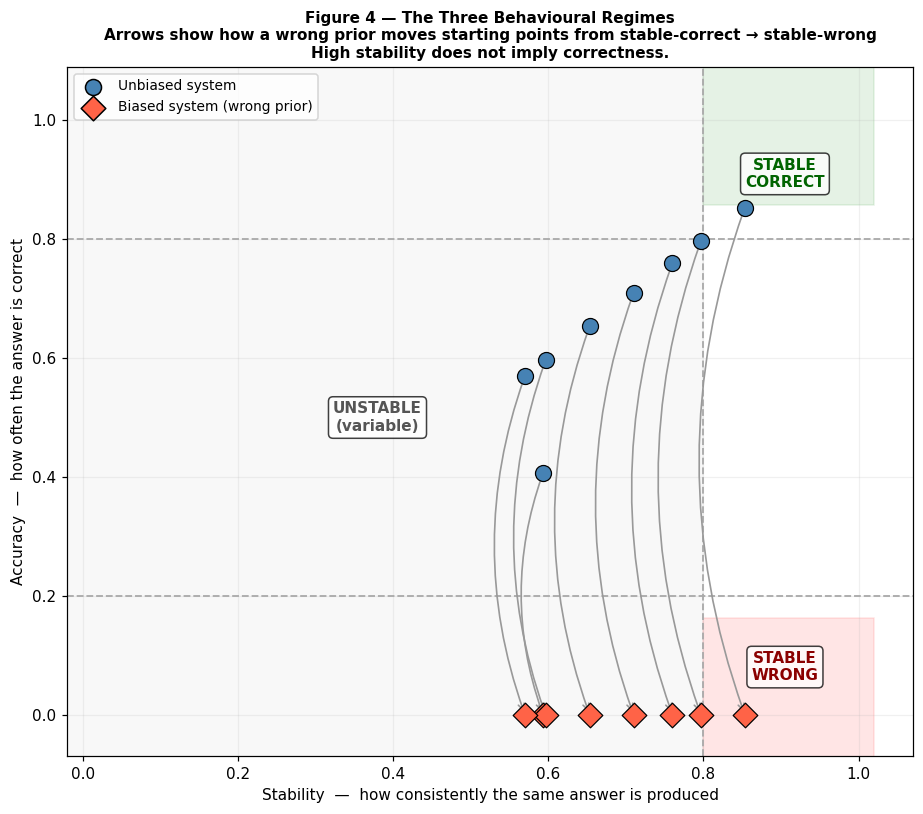

Starting states that become stable-wrong under the biased system:
Start state          Dominant output         Stability   Accuracy
------------------------------------------------------------------
(1, 1, -1)           (1, 1, 1)                    0.85       0.00


In [6]:
target = pattern_1.copy()
records = []

for x0 in states:
    base   = run_trials(x0, W1, target, trials=300, steps=5,
                        bias=None, flip_prob=0.25, seed=11)
    biased = run_trials(x0, W1, target, trials=300, steps=5,
                        bias=bias_wrong, flip_prob=0.25, seed=11)
    records.append({
        "x0":     x0,
        "base_s": base["stability"],   "base_a":  base["accuracy"],
        "bias_s": biased["stability"], "bias_a":  biased["accuracy"],
        "bias_mode": biased["mode"],
    })

fig, ax = plt.subplots(figsize=(8.5, 7.5))

# ── Coloured quadrant backgrounds ────────────────────────────────────────────
ax.axvspan(0.80, 1.02, 0.80, 1.02, alpha=0.10, color='green',  zorder=0)
ax.axvspan(0.80, 1.02, -0.02, 0.20, alpha=0.10, color='red',   zorder=0)
ax.axvspan(-0.02, 0.80, -0.02, 1.02, alpha=0.05, color='gray', zorder=0)

# ── Dividing lines ────────────────────────────────────────────────────────────
for yline in [0.2, 0.8]:
    ax.axhline(yline, linestyle='--', linewidth=1.2, color='#aaaaaa')
ax.axvline(0.80, linestyle='--', linewidth=1.2, color='#aaaaaa')

# ── Quadrant labels ───────────────────────────────────────────────────────────
for txt, x, y, col in [
    ("STABLE\nCORRECT",  0.905, 0.91, 'darkgreen'),
    ("STABLE\nWRONG",    0.905, 0.08, 'darkred'),
    ("UNSTABLE\n(variable)", 0.38, 0.50, '#555555'),
]:
    ax.text(x, y, txt, fontsize=10, color=col, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

# ── Plot points and arrows ────────────────────────────────────────────────────
for r in records:
    ax.scatter(r["base_s"], r["base_a"], s=110, color='steelblue',
               edgecolors='k', linewidths=0.8, zorder=4)
    ax.scatter(r["bias_s"], r["bias_a"], s=130, marker='D', color='tomato',
               edgecolors='k', linewidths=0.8, zorder=4)
    ax.annotate("", xy=(r["bias_s"], r["bias_a"]),
                xytext=(r["base_s"],  r["base_a"]),
                arrowprops=dict(arrowstyle="->", color='#999999', lw=1.1,
                                connectionstyle="arc3,rad=0.18"),
                zorder=3)

# ── Manual legend ─────────────────────────────────────────────────────────────
h1 = ax.scatter([], [], s=110, color='steelblue', edgecolors='k', label='Unbiased system')
h2 = ax.scatter([], [], s=130, marker='D', color='tomato', edgecolors='k',
                label='Biased system (wrong prior)')
ax.legend(handles=[h1, h2], fontsize=9, loc='upper left')

ax.set_xlim(-0.02, 1.07)
ax.set_ylim(-0.07, 1.09)
ax.set_xlabel("Stability  —  how consistently the same answer is produced", fontsize=10)
ax.set_ylabel("Accuracy  —  how often the answer is correct", fontsize=10)
ax.set_title("Figure 4 — The Three Behavioural Regimes\n"
             "Arrows show how a wrong prior moves starting points from stable-correct → stable-wrong\n"
             "High stability does not imply correctness.",
             fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.18)
plt.tight_layout()
plt.show()

# Print examples of stable-wrong cases
print("Starting states that become stable-wrong under the biased system:")
print(f"{'Start state':<20} {'Dominant output':<22} {'Stability':>10} {'Accuracy':>10}")
print("-" * 66)
for r in records:
    if r["bias_s"] >= 0.80 and r["bias_a"] <= 0.20:
        print(f"{str(tuple(r['x0'])):<20} {str(tuple(r['bias_mode'])):<22} "
              f"{r['bias_s']:>10.2f} {r['bias_a']:>10.2f}")


**Interpretation — the core result**

> **A system can be highly stable and completely wrong. These are independent properties.**

The blue circles (unbiased) cluster in the stable-correct quadrant: the system reliably reconstructs the stored pattern. The red diamonds (biased) shift to the stable-wrong quadrant: the same system, under the same learned weights, but with an additional wrong prior, now reliably reconstructs a *different*, incorrect pattern.

In both cases the system is operating perfectly from its own perspective. It is descending the energy landscape and converging on a low-energy state. The difference lies entirely in the structure of the landscape.

This is the minimal mechanistic model of confabulation — and the same phenomenon we observe empirically in large language models in the companion notebook (`y_attractor_prompt.ipynb`), where the model reliably computes with Y=2 regardless of what the prompt states, because the internal constraint landscape contains a strong Y=2 attractor.

**The critical implication for correcting errors:**

Telling a system the correct answer (adding a competing input) does not change the landscape — it only modifies the initial conditions slightly. If the wrong attractor is deeper than the competing input is strong, the trajectory will still converge incorrectly. To change the output, you must change the landscape itself — which in practice means **closing off alternative trajectories**, not reinforcing the correct one.


---

## Section 5: Constraint Closure is Local, Not Persistent

**Question: if we constrain the system correctly at step 1, does it stay correct across multiple steps?**

This section introduces a finding that mirrors one of the most important results in the LLM experiment: **constraint closure does not propagate**.

Even if we start the system in the correct state (perfectly constrained at step zero), subsequent dynamics — operating under a biased constraint landscape — will progressively erode accuracy. The correct answer at step 0 does not protect against wrong attractors at step 1, 2, 3...

This has direct implications for **multi-step reasoning**, both in AI systems and in human cognition:

- A chain of reasoning is only as reliable as its weakest constraint step
- Correct intermediate conclusions can be overwritten by strong priors at later steps
- Re-constraining at each step is required — not just at the start

This is why patients with certain confabulatory conditions can produce correct single-step inferences but lose coherence across a narrative: each step is a fresh trajectory through the same biased landscape.


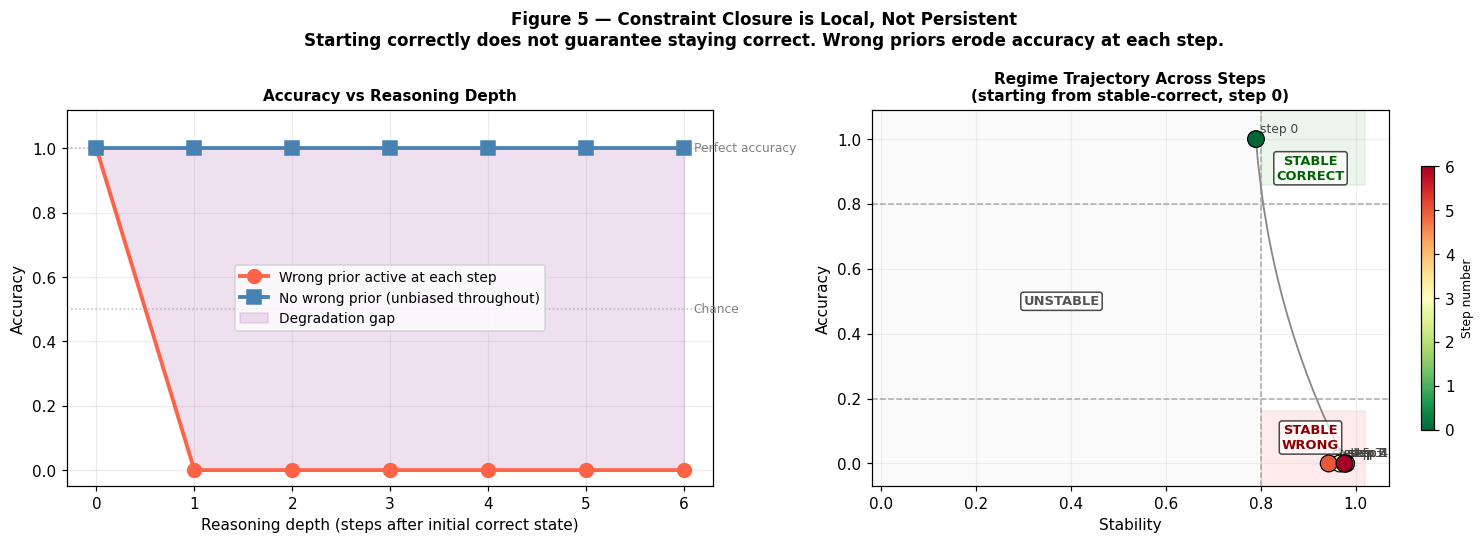

In [7]:
def run_chain_degradation(initial_state, W, bias_subsequent, n_steps, trials=300, seed=42):
    """
    Step 0: system starts at initial_state (correctly constrained).
    Steps 1..k: system evolves under the biased landscape.
    Returns accuracy at each step depth k = 0, 1, ..., n_steps-1.
    """
    rng = np.random.default_rng(seed)
    step_accuracy = []
    for depth in range(n_steps):
        correct = 0
        for _ in range(trials):
            x = initial_state.copy()
            # Apply 'depth' subsequent biased updates
            for _ in range(depth):
                order = rng.permutation(len(x))
                x = async_update(x, W, bias=bias_subsequent, order=order)
            if np.array_equal(x, target):
                correct += 1
        step_accuracy.append(correct / trials)
    return step_accuracy

# Start from the correct state
correct_start = pattern_1.copy()

acc_biased    = run_chain_degradation(correct_start, W1, bias_wrong,      n_steps=7)
acc_unbiased  = run_chain_degradation(correct_start, W1, np.zeros(3),     n_steps=7)

steps = list(range(len(acc_biased)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: accuracy over steps ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(steps, acc_biased,   'o-', color='tomato',    linewidth=2.5, markersize=9,
        label="Wrong prior active at each step")
ax.plot(steps, acc_unbiased, 's-', color='steelblue', linewidth=2.5, markersize=9,
        label="No wrong prior (unbiased throughout)")
ax.fill_between(steps, acc_biased, acc_unbiased,
                alpha=0.12, color='purple', label="Degradation gap")

for y, lab, col in [(1.0,'Perfect accuracy','gray'), (0.5,'Chance','gray')]:
    ax.axhline(y, linestyle=':', linewidth=1, color=col, alpha=0.5)
    ax.text(6.1, y, lab, fontsize=8, va='center', color='gray')

ax.set_xlabel("Reasoning depth (steps after initial correct state)", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_ylim(-0.05, 1.12)
ax.set_title("Accuracy vs Reasoning Depth", fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# ── Right: regime trajectory — does the system stay stable-correct? ───────────
ax = axes[1]

# Compute stability at each depth for biased case
stabilities_biased = []
for depth in range(len(steps)):
    rng2 = np.random.default_rng(99)
    outputs = []
    for _ in range(300):
        x = perturb_state(correct_start, flip_prob=0.1, rng=rng2)
        for _ in range(depth):
            order = rng2.permutation(len(x))
            x = async_update(x, W1, bias=bias_wrong, order=order)
        outputs.append(tuple(x))
    outputs = np.array(outputs)
    unique, counts = np.unique(outputs, axis=0, return_counts=True)
    stabilities_biased.append(counts.max() / 300)

# Plot trajectory through stability-accuracy space
sc = ax.scatter(stabilities_biased, acc_biased,
                c=steps, cmap='RdYlGn_r', s=120,
                edgecolors='k', linewidths=0.8, zorder=4)
for i in range(1, len(steps)):
    ax.annotate("", xy=(stabilities_biased[i], acc_biased[i]),
                xytext=(stabilities_biased[i-1], acc_biased[i-1]),
                arrowprops=dict(arrowstyle="->", color='#888888', lw=1.2,
                                connectionstyle="arc3,rad=0.1"))
for i, step in enumerate(steps):
    ax.text(stabilities_biased[i]+0.008, acc_biased[i]+0.02,
            f"step {step}", fontsize=8, color='#444444')

# Quadrant shading
ax.axvspan(0.80, 1.02, 0.80, 1.02, alpha=0.08, color='green')
ax.axvspan(0.80, 1.02, -0.02, 0.20, alpha=0.08, color='red')
ax.axvspan(-0.02, 0.80, -0.02, 1.02, alpha=0.04, color='gray')
for yline in [0.2, 0.8]:
    ax.axhline(yline, linestyle='--', linewidth=1, color='#aaaaaa')
ax.axvline(0.80, linestyle='--', linewidth=1, color='#aaaaaa')
for txt, x, y, col in [
    ("STABLE\nCORRECT", 0.905, 0.91, 'darkgreen'),
    ("STABLE\nWRONG",   0.905, 0.08, 'darkred'),
    ("UNSTABLE",        0.38,  0.50,  '#555555'),
]:
    ax.text(x, y, txt, fontsize=8.5, color=col, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

cb = plt.colorbar(sc, ax=ax, shrink=0.7)
cb.set_label("Step number", fontsize=8)
ax.set_xlim(-0.02, 1.07); ax.set_ylim(-0.07, 1.09)
ax.set_xlabel("Stability", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_title("Regime Trajectory Across Steps\n(starting from stable-correct, step 0)", fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.18)

plt.suptitle("Figure 5 — Constraint Closure is Local, Not Persistent\n"
             "Starting correctly does not guarantee staying correct. Wrong priors erode accuracy at each step.",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation**

The left panel shows that accuracy degrades monotonically as reasoning depth increases — even though the system *starts* in the correct state. The wrong prior reasserts itself at each subsequent step.

The right panel shows this as a trajectory through the stability-accuracy space. The system begins in the stable-correct quadrant (step 0) and migrates toward the stable-wrong quadrant as reasoning depth increases. Stability is maintained throughout — the system remains confident — but accuracy falls away.

This is the mechanistic explanation for a finding in the companion LLM experiment: constraint closure achieved at one point in a reasoning chain does not propagate to subsequent steps. Each step is a fresh trajectory through the same biased landscape. The correct answer must be re-enforced at each step, or the wrong attractor will reclaim the trajectory.

> **Correctness at step N does not imply correctness at step N+1.** This is not a failure of the system — it is a direct consequence of the architecture.


---

## Summary

This notebook has demonstrated five connected results using a minimal Hopfield memory model:

| Figure | Result | DLMH implication |
|---|---|---|
| 1 — Energy landscape | Memories are valleys in a distributed constraint landscape | No single point of failure; interference is architectural |
| 2 — Trajectories | Recall is active reconstruction, not retrieval | Both correct and incorrect recall descend energy; the landscape determines which |
| 3 — Walsh spectrum | More stored patterns = richer, more interference-prone landscape | LLMs with massive training have extremely complex constraint landscapes |
| 4 — Three regimes | Stable-wrong convergence is possible and distinct from instability | Confabulation is confident, repeatable, wrong — not random noise |
| 5 — Degradation | Constraint closure is local, not persistent | Multi-step reasoning requires re-constraining at each step |

---

## The bridge to the companion experiment

The results in this notebook are **predictions**. They follow from the mathematical structure of distributed memory systems.

The companion notebook (`y_attractor_prompt__1_.ipynb`) provides the **empirical confirmation**: all five of these results are observed in a real large language model (Mistral-7B), using a carefully controlled behavioural experiment.

The fact that the same phenomena appear in two architecturally different systems — a minimal Hopfield model and a transformer-based LLM — is the central argument of DLMH: **stable-wrong convergence is a property of distributed reconstruction under insufficient constraint, not a quirk of any particular implementation**.

---

## Connection to human memory

The same five results have direct counterparts in the human memory literature:

- **Graceful degradation** → neural damage degrades memory gradually (Squire, 2004)
- **Structured confabulation** → false recalls are semantically coherent, not random (Schacter, 2011)
- **Stable-wrong convergence** → post-event misinformation produces confident, stable false memories (Loftus, 1979)
- **Recognition before recall** → similarity alignment precedes full reconstruction (Yonelinas, 2002)
- **Multi-step degradation** → source monitoring errors accumulate across retrieval steps (Johnson et al., 1993)

For the full theoretical framework see: `DLMH.pdf`
